<a href="https://colab.research.google.com/github/benasphy/Eduera_ML_Projects/blob/main/K_Means_Implementation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Loan Approval using K-Means**

**Import necessary libraries**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

**Data Preparation**

In [3]:
# Simulated dataset for loan applicants
data = {
    'Applicant_ID': range(1, 21),
    'Annual_Income': np.random.randint(30000, 120000, 20),
    'Credit_Score': np.random.randint(300, 850, 20),
    'Loan_Amount': np.random.randint(5000, 50000, 20),
    'Debt_to_Income_Ratio': np.random.uniform(0.1, 0.5, 20)
}
df = pd.DataFrame(data)
df.head()

,Applicant_ID,Annual_Income,Credit_Score,Loan_Amount,Debt_to_Income_Ratio
0,1,76904,584,24685,0.408434
1,2,79551,688,37856,0.119036
2,3,57816,804,37502,0.220604
3,4,111709,579,20946,0.114083
4,5,32651,599,43084,0.320629


**Feature Selection and Scaling**

In [4]:
X = df[["Annual_Income", "Credit_Score", "Loan_Amount", "Debt_to_Income_Ratio"]]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

**Applying K-Means Clustering**

In [5]:
kmeans = KMeans(n_clusters=3, random_state = 42, n_init=10)
df["Risk Category"] = kmeans.fit_predict(X_scaled)

**Interpreting the Clusters**

In [8]:
risk_labels = {0: "Low Risk", 1: "Medium Risk", 2: "High Risk"}
df["Risk Category"] = df["Risk Category"].map(risk_labels)

**Visualizing the Clusters (PCA)**

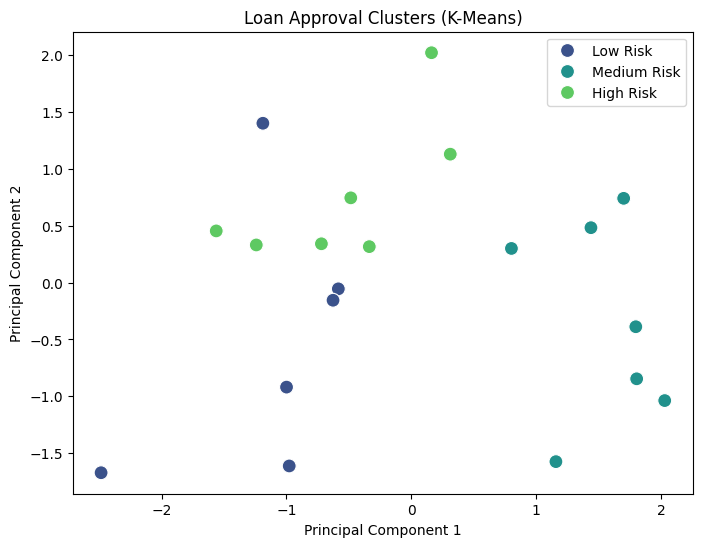

In [9]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df["PCA1"] = X_pca[:, 0]
df["PCA2"] = X_pca[:, 1]

plt.figure(figsize = (8,6))
sns.scatterplot(x=df["PCA1"], y=df["PCA2"], hue = df["Risk Category"], palette = "viridis", s=100)
plt.title("Loan Approval Clusters (K-Means)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.show()

**Final Output**

In [10]:
print(df[["Applicant_ID",	"Annual_Income",	"Credit_Score",	"Loan_Amount", "Risk Category"]])

    Applicant_ID  Annual_Income  Credit_Score  Loan_Amount Risk Category
0              1          76904           584        24685      Low Risk
1              2          79551           688        37856   Medium Risk
2              3          57816           804        37502   Medium Risk
3              4         111709           579        20946     High Risk
4              5          32651           599        43084   Medium Risk
5              6         118296           691        16538      Low Risk
6              7          39498           648        38194   Medium Risk
7              8          92468           351        41074     High Risk
8              9          77419           525        14935     High Risk
9             10          72188           529        15452     High Risk
10            11          78579           789        32831   Medium Risk
11            12          82649           326        16824     High Risk
12            13          30811           535      

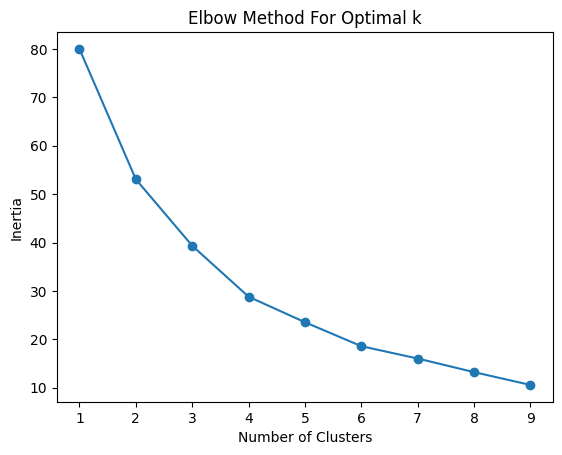

In [11]:
inertia = []
for k in range(1, 10):
    model = KMeans(n_clusters=k, n_init=10, random_state=42)
    model.fit(X_scaled)
    inertia.append(model.inertia_)

plt.plot(range(1, 10), inertia, marker='o')
plt.title('Elbow Method For Optimal k')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.show()
